# Experiment Results and Ablation Analysis

Notebook đọc raw run, chuẩn hóa result catalog, kiểm tra provenance,
tổng hợp nhiều seed và sinh toàn bộ hình báo cáo. Metric không được nhập tay.

In [1]:
from pathlib import Path
import json
import statistics

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "artifacts").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy project root")


PROJECT_ROOT = find_project_root(Path.cwd())
RUN_ROOT = PROJECT_ROOT / "artifacts" / "runs"
CATALOG_PATH = PROJECT_ROOT / "artifacts" / "metrics" / "sprint2_results.json"
FIGURE_DIR = PROJECT_ROOT / "artifacts" / "figures" / "sprint2"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
REBUILD_CATALOG_FROM_LOCAL_RUNS = False

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Chuẩn hóa raw experiment artifacts

`artifacts/runs/` chứa checkpoint và output timestamp nên được ignore. Catalog nhỏ,
ổn định và có thể commit chỉ giữ metadata, metric và learning history cần cho báo cáo.

In [2]:
CATALOG_SCHEMA_VERSION = 1


def read_json(path: Path) -> dict:
    payload = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(payload, dict):
        raise ValueError(f"JSON root phải là object: {path}")
    return payload


def discover_comparison_files(run_root: Path) -> tuple[Path, ...]:
    if not run_root.is_dir():
        raise FileNotFoundError(f"Không tìm thấy run directory: {run_root}")
    return tuple(sorted(run_root.glob("*/comparison.json")))


def metric_value(run: dict, split: str, metric: str) -> float:
    try:
        return float(run[split][metric])
    except (KeyError, TypeError, ValueError) as error:
        raise ValueError(f"Run thiếu metric {split}.{metric}") from error


def build_result_catalog(comparison_paths) -> dict:
    """Flatten timestamped comparisons into deterministic tabular records."""
    experiments, runs, history, run_ids = [], [], [], set()
    paths = sorted(Path(path) for path in comparison_paths)
    if not paths:
        raise ValueError("Không tìm thấy comparison.json")

    for comparison_path in paths:
        comparison = read_json(comparison_path)
        config_path = comparison_path.with_name("config.json")
        config = read_json(config_path) if config_path.is_file() else {}
        experiment = str(comparison.get("run_name", config.get("run_name", ""))).strip()
        if not experiment:
            raise ValueError(f"Run thiếu run_name: {comparison_path}")
        metadata = {
            "experiment": experiment,
            "run_directory": comparison_path.parent.name,
            "mode": comparison.get("mode", config.get("mode", "full")),
            "models": list(comparison.get("models", {}).keys()),
            "seeds": list(config.get("seeds", [])),
            "feature_mode": comparison.get("feature_mode", config.get("feature_mode", "raw")),
            "feature_standardization": comparison.get(
                "feature_standardization", config.get("feature_standardization", "none")
            ),
            "graph_direction": comparison.get("graph_direction", config.get("graph_direction", "directed")),
            "symmetrization_policy": comparison.get("symmetrization_policy", "none"),
            "graph_edge_count": comparison.get("graph_edge_count"),
            "uses_graph_structure": comparison.get("uses_graph_structure", True),
            "relation_mode": comparison.get("relation_mode", config.get("relation_mode", "original")),
            "selection_metric": comparison.get("selection_metric", "validation.average_precision"),
            "test_used_for_selection": bool(comparison.get("test_used_for_selection", False)),
            "is_partial_evaluation": bool(comparison.get("is_partial_evaluation", False)),
            "data_sha256": comparison.get("data_sha256"),
            "elapsed_seconds": comparison.get("elapsed_seconds"),
            "environment": comparison.get("environment", {}),
        }
        experiments.append(metadata)

        for model_name, model_payload in sorted(comparison["models"].items()):
            for model_run in sorted(model_payload.get("runs", []), key=lambda item: int(item["seed"])):
                seed = int(model_run["seed"])
                run_id = f"{experiment}:{model_name}:seed{seed}"
                if run_id in run_ids:
                    raise ValueError(f"Duplicate run ID: {run_id}")
                run_ids.add(run_id)
                runs.append(
                    {
                        "run_id": run_id,
                        "experiment": experiment,
                        "model": model_name,
                        "seed": seed,
                        "feature_mode": metadata["feature_mode"],
                        "feature_standardization": metadata["feature_standardization"],
                        "graph_direction": metadata["graph_direction"],
                        "symmetrization_policy": metadata["symmetrization_policy"],
                        "relation_mode": metadata["relation_mode"],
                        "parameter_count": int(model_run["parameter_count"]),
                        "positive_weight": float(model_run["positive_weight"]),
                        "best_epoch": int(model_run["best_epoch"]),
                        "epochs_completed": int(model_run["epochs_completed"]),
                        "stopped_early": bool(model_run["stopped_early"]),
                        "validation_roc_auc": metric_value(model_run, "validation", "roc_auc"),
                        "validation_average_precision": metric_value(model_run, "validation", "average_precision"),
                        "test_roc_auc": metric_value(model_run, "test", "roc_auc"),
                        "test_average_precision": metric_value(model_run, "test", "average_precision"),
                        "run_elapsed_seconds": model_run.get("run_elapsed_seconds"),
                        "sampling_protocol": model_run.get("sampling_protocol"),
                        "query_time": model_run.get("query_time"),
                        "uses_graph_structure": model_run.get("uses_graph_structure", True),
                    }
                )
                for epoch_record in model_run.get("history", []):
                    validation = epoch_record["validation"]
                    history.append(
                        {
                            "run_id": run_id,
                            "epoch": int(epoch_record["epoch"]),
                            "train_loss": float(epoch_record["train_loss"]),
                            "validation_roc_auc": float(validation["roc_auc"]),
                            "validation_average_precision": float(validation["average_precision"]),
                            "seconds": float(epoch_record["seconds"]),
                        }
                    )
    return {
        "schema_version": CATALOG_SCHEMA_VERSION,
        "experiments": experiments,
        "runs": runs,
        "history": history,
    }


def load_result_catalog(path: Path) -> dict:
    catalog = read_json(path)
    if catalog.get("schema_version") != CATALOG_SCHEMA_VERSION:
        raise ValueError(f"Unsupported catalog schema: {catalog.get('schema_version')}")
    for key in ("experiments", "runs", "history"):
        if not isinstance(catalog.get(key), list):
            raise ValueError(f"Catalog thiếu list {key}")
    return catalog

In [3]:
if REBUILD_CATALOG_FROM_LOCAL_RUNS:
    catalog = build_result_catalog(discover_comparison_files(RUN_ROOT))
    CATALOG_PATH.write_text(
        json.dumps(catalog, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )
    print("Đã rebuild catalog từ raw local runs.")
else:
    catalog = load_result_catalog(CATALOG_PATH)

runs_df = pd.DataFrame(catalog["runs"])
history_df = pd.DataFrame(catalog["history"])
experiments_df = pd.DataFrame(catalog["experiments"])
print(f"{len(experiments_df)} experiments | {len(runs_df)} model-seed runs | {len(history_df)} epoch records")

9 experiments | 36 model-seed runs | 1007 epoch records


## 2. Kiểm tra provenance và protocol

Trước khi so sánh metric, xác nhận mọi experiment dùng cùng dataset fingerprint,
không dùng test để chọn checkpoint và không trộn partial evaluation vào báo cáo.

In [4]:
assert experiments_df["data_sha256"].nunique() == 1, "Các run không cùng dataset fingerprint"
assert not experiments_df["test_used_for_selection"].any(), "Có run dùng test để lựa chọn"
assert not experiments_df["is_partial_evaluation"].any(), "Catalog chứa partial evaluation"

display(experiments_df[[
    "experiment", "models", "feature_mode", "feature_standardization",
    "graph_direction", "relation_mode", "selection_metric", "data_sha256",
]])

,experiment,models,feature_mode,feature_standardization,graph_direction,relation_mode,selection_metric,data_sha256
0,baseline_full,"[gcn, graphsage]",raw,none,directed,original,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...
1,baseline_full_zero_indicator,"[gcn, graphsage]",zero_indicator,none,directed,original,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...
2,gcn_ablation_dropout0,[gcn],zero_indicator,none,directed,original,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...
3,gcn_ablation_lr001,[gcn],zero_indicator,none,directed,original,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...
4,gcn_ablation_standardized,[gcn],zero_indicator,global_zscore,directed,original,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...
5,gcn_ablation_weight_decay_5e7,[gcn],zero_indicator,none,directed,original,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...
6,gcn_graphsage_ablation_undirected,"[gcn, graphsage]",zero_indicator,none,undirected,original,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...
7,mlp_zero_indicator,[mlp],zero_indicator,none,not_applicable,original,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...
8,rgcn_background_full,[rgcn],zero_indicator,none,directed,target_background,validation.average_precision,95470dab2c48523f7118a92204c090de37a957bb053bd5...


## 3. Bảng tổng hợp toàn bộ experiment

Độ lệch chuẩn dùng population standard deviation (`ddof=0`) để thống nhất với artifact.

In [5]:
METRICS = [
    "validation_roc_auc", "validation_average_precision",
    "test_roc_auc", "test_average_precision",
]
summary_rows = []
for (experiment, model_name), group in runs_df.groupby(["experiment", "model"], sort=True):
    row = {
        "experiment": experiment,
        "model": model_name,
        "seeds": group["seed"].nunique(),
        "parameters": int(group["parameter_count"].iloc[0]),
    }
    for metric in METRICS:
        row[f"{metric}_mean"] = group[metric].mean()
        row[f"{metric}_std"] = group[metric].std(ddof=0)
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(6))

,experiment,model,seeds,parameters,validation_roc_auc_mean,validation_roc_auc_std,validation_average_precision_mean,validation_average_precision_std,test_roc_auc_mean,test_roc_auc_std,test_average_precision_mean,test_average_precision_std
0,baseline_full,gcn,3,1217,0.671084,0.000393,0.024991,0.000059,0.681957,0.000872,0.027691,0.000117
1,baseline_full,graphsage,3,2369,0.750582,0.000443,0.034868,0.000036,0.758562,0.000857,0.038309,0.000074
2,baseline_full_zero_indicator,gcn,3,2305,0.673327,0.000777,0.025638,0.000107,0.685631,0.000929,0.028441,0.000212
3,baseline_full_zero_indicator,graphsage,3,4545,0.751388,0.000539,0.035396,0.000067,0.758553,0.000816,0.038601,0.000242
4,gcn_ablation_dropout0,gcn,3,2305,0.674312,0.001607,0.025595,0.000188,0.684688,0.003102,0.028833,0.000488
5,gcn_ablation_lr001,gcn,3,2305,0.664749,0.001717,0.024187,0.000103,0.672862,0.002968,0.025956,0.000190
6,gcn_ablation_standardized,gcn,3,2305,0.672151,0.000374,0.025239,0.000025,0.685454,0.000338,0.027482,0.000127
7,gcn_ablation_weight_decay_5e7,gcn,3,2305,0.673765,0.001834,0.025983,0.000157,0.685957,0.002712,0.029182,0.000300
8,gcn_graphsage_ablation_undirected,gcn,3,2305,0.743221,0.000953,0.035593,0.000126,0.749892,0.000737,0.035248,0.000255
9,gcn_graphsage_ablation_undirected,graphsage,3,4545,0.768470,0.001313,0.038611,0.000316,0.777018,0.001842,0.043408,0.000346


In [6]:
def aggregate(experiment: str, model_name: str) -> dict[str, tuple[float, float]]:
    selected = runs_df.query("experiment == @experiment and model == @model_name")
    if selected.empty:
        raise KeyError(f"Không có kết quả cho {experiment}/{model_name}")
    return {
        metric: (float(selected[metric].mean()), float(selected[metric].std(ddof=0)))
        for metric in METRICS
    }


def plot_metric_pairs(results: dict, title: str, output_name: str | None) -> None:
    labels = list(results)
    positions = np.arange(len(labels))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for axis, metric, metric_title in (
        (axes[0], "test_roc_auc", "Test ROC-AUC"),
        (axes[1], "test_average_precision", "Test Average Precision"),
    ):
        means = [results[label][metric][0] for label in labels]
        standard_deviations = [results[label][metric][1] for label in labels]
        axis.bar(
            positions,
            means,
            yerr=standard_deviations,
            capsize=4,
            color=plt.cm.Set2(np.linspace(0, 1, len(labels))),
        )
        axis.set_xticks(positions, labels, rotation=18, ha="right")
        axis.set_title(metric_title)
        axis.set_ylim(0, max(means) * 1.18)
    fig.suptitle(title)
    plt.tight_layout()
    if output_name is not None:
        fig.savefig(FIGURE_DIR / output_name, dpi=160, bbox_inches="tight")
    plt.show()

## 4. Raw 17D so với zero-indicator 34D

So sánh giữ nguyên split, seed, hidden size, sampling và ngân sách huấn luyện; khác biệt
chủ đích là cách biểu diễn missing value.

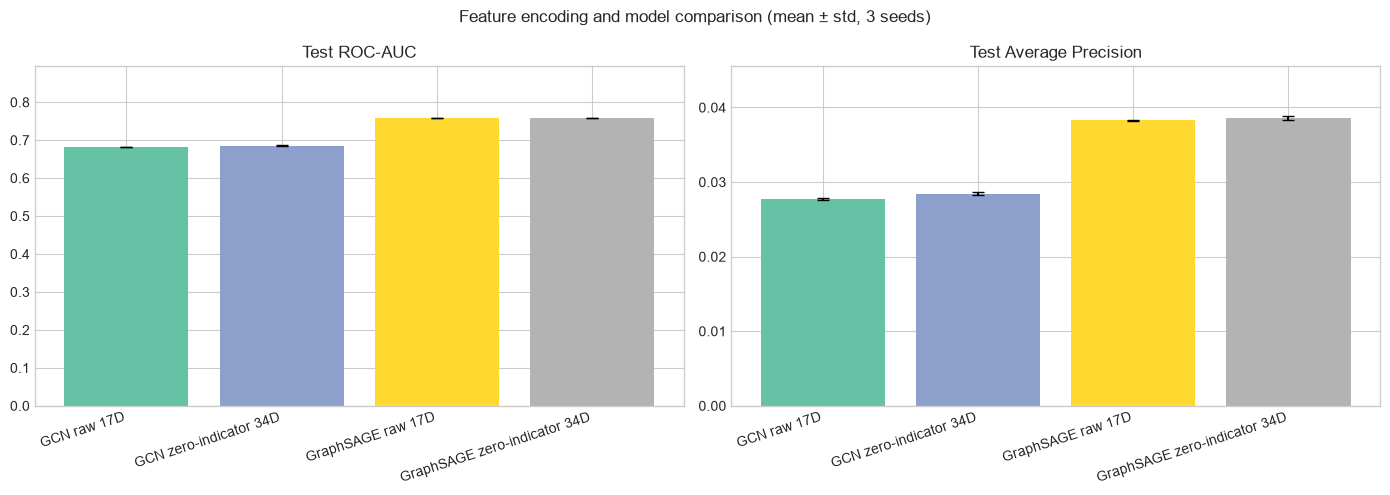

In [7]:
feature_results = {
    "GCN raw 17D": aggregate("baseline_full", "gcn"),
    "GCN zero-indicator 34D": aggregate("baseline_full_zero_indicator", "gcn"),
    "GraphSAGE raw 17D": aggregate("baseline_full", "graphsage"),
    "GraphSAGE zero-indicator 34D": aggregate("baseline_full_zero_indicator", "graphsage"),
}
plot_metric_pairs(
    feature_results,
    "Feature encoding and model comparison (mean ± std, 3 seeds)",
    "01_feature_encoding.png",
)

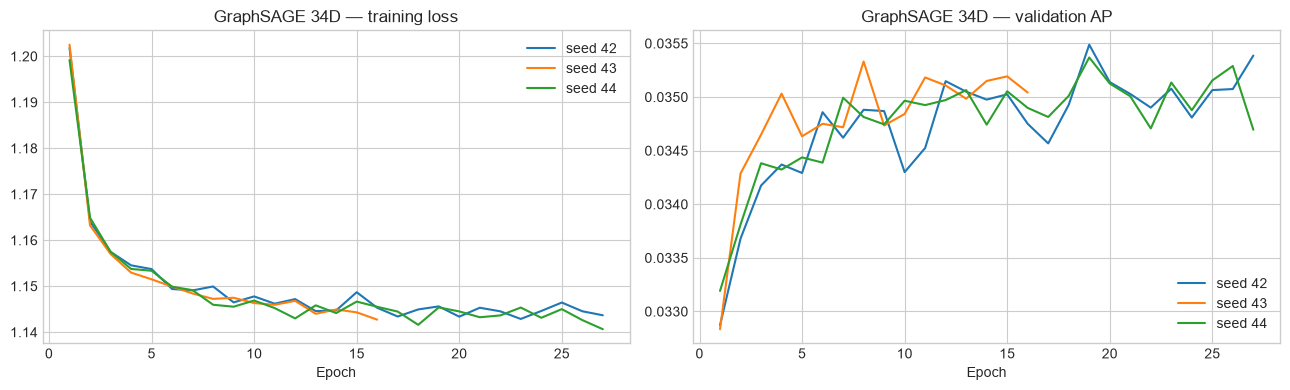

In [8]:
selected_runs = runs_df.query(
    "experiment == 'baseline_full_zero_indicator' and model == 'graphsage'"
)
selected_history = history_df[history_df["run_id"].isin(selected_runs["run_id"])]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for run_id, group in selected_history.groupby("run_id"):
    seed = run_id.rsplit("seed", 1)[-1]
    axes[0].plot(group["epoch"], group["train_loss"], label=f"seed {seed}")
    axes[1].plot(group["epoch"], group["validation_average_precision"], label=f"seed {seed}")
axes[0].set_title("GraphSAGE 34D — training loss")
axes[1].set_title("GraphSAGE 34D — validation AP")
for axis in axes:
    axis.set_xlabel("Epoch")
    axis.legend()
plt.tight_layout()
plt.show()

## 5. Tác động của hướng message passing

Undirected là ablation thêm cạnh ngược rồi coalesce. Kết quả tốt hơn không có nghĩa
quan hệ khẩn cấp gốc có bản chất vô hướng.

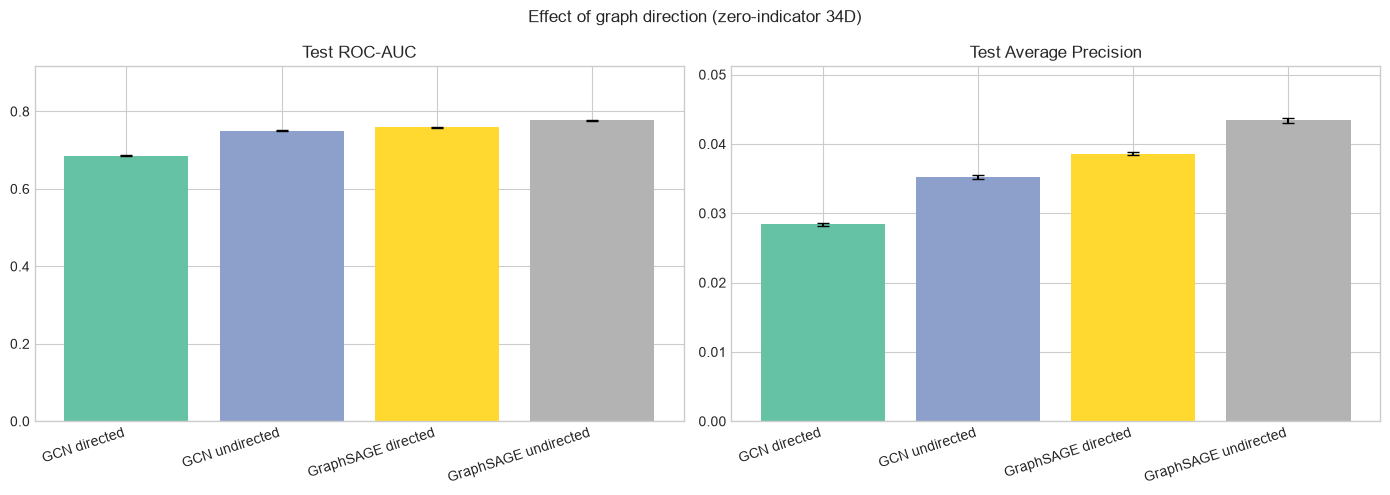

In [9]:
direction_results = {
    "GCN directed": aggregate("baseline_full_zero_indicator", "gcn"),
    "GCN undirected": aggregate("gcn_graphsage_ablation_undirected", "gcn"),
    "GraphSAGE directed": aggregate("baseline_full_zero_indicator", "graphsage"),
    "GraphSAGE undirected": aggregate("gcn_graphsage_ablation_undirected", "graphsage"),
}
plot_metric_pairs(
    direction_results,
    "Effect of graph direction (zero-indicator 34D)",
    "03_graph_direction.png",
)

## 6. One-factor-at-a-time GCN ablation

Mỗi run chỉ thay đổi một yếu tố so với GCN zero-indicator 34D directed. Delta dương
nghĩa là tốt hơn baseline.

delta percentage points,validation_roc_auc,validation_average_precision,test_roc_auc,test_average_precision
change,,,,
Global z-score,-0.1177,-0.0399,-0.0177,-0.0959
Dropout 0.5 → 0.0,0.0985,-0.0044,-0.0943,0.0392
Weight decay 5e-4 → 5e-7,0.0437,0.0345,0.0327,0.0742
Learning rate 0.001 → 0.01,-0.8579,-0.1451,-1.2768,-0.2485
Directed → undirected,6.9894,0.9955,6.4261,0.6807


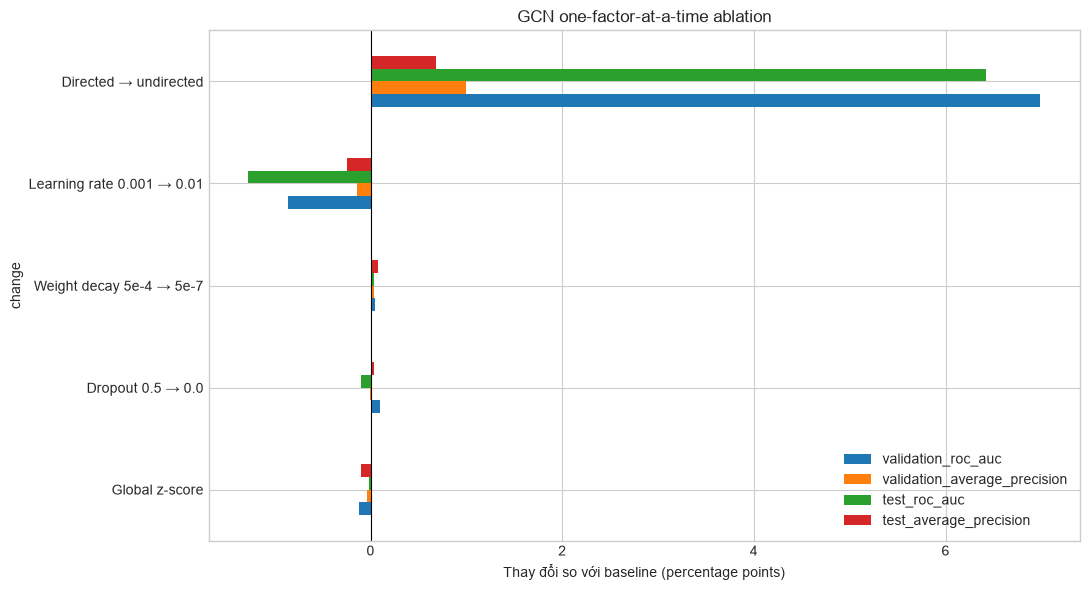

In [10]:
ablation_experiments = {
    "Global z-score": "gcn_ablation_standardized",
    "Dropout 0.5 → 0.0": "gcn_ablation_dropout0",
    "Weight decay 5e-4 → 5e-7": "gcn_ablation_weight_decay_5e7",
    "Learning rate 0.001 → 0.01": "gcn_ablation_lr001",
    "Directed → undirected": "gcn_graphsage_ablation_undirected",
}
baseline = aggregate("baseline_full_zero_indicator", "gcn")
ablation_rows = []
for label, experiment in ablation_experiments.items():
    current = aggregate(experiment, "gcn")
    row = {"change": label}
    for metric in METRICS:
        row[metric] = current[metric][0] - baseline[metric][0]
    ablation_rows.append(row)
ablation_df = pd.DataFrame(ablation_rows).set_index("change")
display((ablation_df * 100).round(4).rename_axis(columns="delta percentage points"))

ax = (ablation_df * 100).plot.barh(figsize=(11, 6))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Thay đổi so với baseline (percentage points)")
ax.set_title("GCN one-factor-at-a-time ablation")
plt.tight_layout()
ax.figure.savefig(FIGURE_DIR / "02_gcn_ablation.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. RGCN và vai trò background

RGCN-BG dùng bốn relation `T→T`, `T→B`, `B→T`, `B→B`; normal và fraud đều thuộc T
nên relation không tiết lộ fraud identity. Hidden size được giảm để số tham số gần GCN.

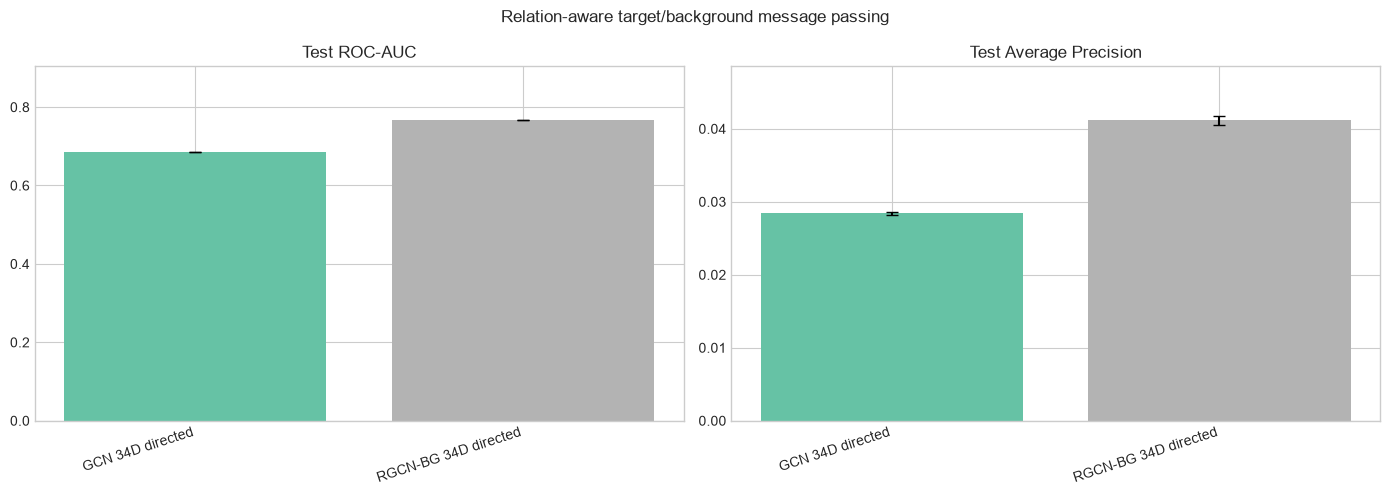

,experiment,model,parameter_count
0,baseline_full_zero_indicator,gcn,2305
1,baseline_full_zero_indicator,graphsage,4545
2,rgcn_background_full,rgcn,2289


In [11]:
background_results = {
    "GCN 34D directed": aggregate("baseline_full_zero_indicator", "gcn"),
    "RGCN-BG 34D directed": aggregate("rgcn_background_full", "rgcn"),
}
plot_metric_pairs(
    background_results,
    "Relation-aware target/background message passing",
    None,
)

parameter_table = runs_df[
    runs_df["experiment"].isin(["baseline_full_zero_indicator", "rgcn_background_full"])
].groupby(["experiment", "model"], as_index=False)["parameter_count"].first()
display(parameter_table)

## 8. Tiến triển qua các cấu hình chính

Biểu đồ đặt baseline MLP feature-only cạnh các mốc GNN chính để thấy phần đóng góp của feature, cấu trúc graph và kiến trúc. RGCN-BG là một nhánh directed độc lập, không phải bước cộng dồn sau GraphSAGE undirected.

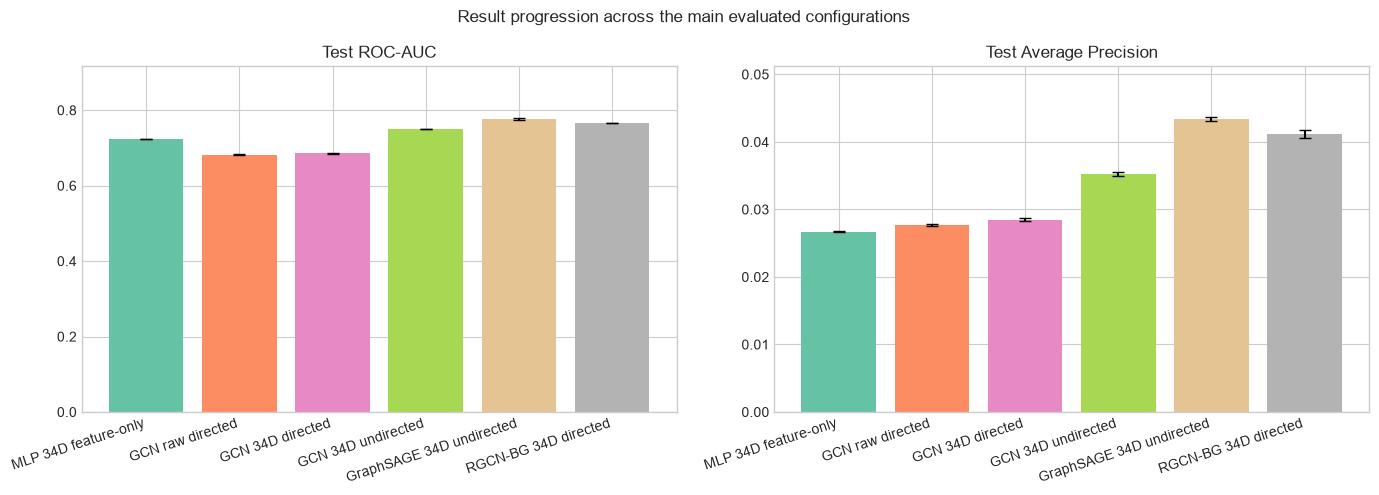

In [12]:
progression_results = {
    "MLP 34D feature-only": aggregate("mlp_zero_indicator", "mlp"),
    "GCN raw directed": aggregate("baseline_full", "gcn"),
    "GCN 34D directed": aggregate("baseline_full_zero_indicator", "gcn"),
    "GCN 34D undirected": aggregate("gcn_graphsage_ablation_undirected", "gcn"),
    "GraphSAGE 34D undirected": aggregate("gcn_graphsage_ablation_undirected", "graphsage"),
    "RGCN-BG 34D directed": aggregate("rgcn_background_full", "rgcn"),
}
plot_metric_pairs(
    progression_results,
    "Result progression across the main evaluated configurations",
    "04_result_progression.png",
)

## 9. Chọn cấu hình mạnh nhất

Việc xếp hạng dùng **validation AP**. Test metric chỉ được trình bày sau quyết định này.

In [13]:
ranked = summary_df.sort_values("validation_average_precision_mean", ascending=False)
display(ranked[[
    "experiment", "model", "validation_average_precision_mean",
    "validation_average_precision_std", "test_roc_auc_mean",
    "test_average_precision_mean", "parameters",
]].round(6))

winner = ranked.iloc[0]
print(
    f"Chọn theo validation AP: {winner['model']} / {winner['experiment']} "
    f"với valid AP={winner['validation_average_precision_mean']:.6f}."
)

,experiment,model,validation_average_precision_mean,validation_average_precision_std,test_roc_auc_mean,test_average_precision_mean,parameters
9,gcn_graphsage_ablation_undirected,graphsage,0.038611,0.000316,0.777018,0.043408,4545
11,rgcn_background_full,rgcn,0.036775,0.000353,0.766536,0.041171,2289
8,gcn_graphsage_ablation_undirected,gcn,0.035593,0.000126,0.749892,0.035248,2305
3,baseline_full_zero_indicator,graphsage,0.035396,0.000067,0.758553,0.038601,4545
1,baseline_full,graphsage,0.034868,0.000036,0.758562,0.038309,2369
10,mlp_zero_indicator,mlp,0.026111,0.000102,0.722830,0.026676,2305
7,gcn_ablation_weight_decay_5e7,gcn,0.025983,0.000157,0.685957,0.029182,2305
2,baseline_full_zero_indicator,gcn,0.025638,0.000107,0.685631,0.028441,2305
4,gcn_ablation_dropout0,gcn,0.025595,0.000188,0.684688,0.028833,2305
6,gcn_ablation_standardized,gcn,0.025239,0.000025,0.685454,0.027482,2305


Chọn theo validation AP: graphsage / gcn_graphsage_ablation_undirected với valid AP=0.038611.


## 10. Benchmark MLP và các GNN 34D

Bảng chính so MLP feature-only với bốn GNN, cùng feature 34D, split,
training budget và seed. MLP dùng node mini-batch và không nhận cạnh. GCN/GraphSAGE/GAT dùng structural coalescing với hai hop
`[15,10]`; TGAT mirror từng temporal event và dùng một hop `[15]` tương ứng một
`TransformerConv`. Vì vậy đây là so sánh pipeline end-to-end; direction không áp dụng cho MLP.


,model,sampling_protocol,symmetrization_policy,seeds,parameters,total_run_seconds,validation_roc_auc_mean,validation_roc_auc_std,validation_average_precision_mean,validation_average_precision_std,test_roc_auc_mean,test_roc_auc_std,test_average_precision_mean,test_average_precision_std
0,MLP,node_minibatch_no_edges,not_applicable,3,2305,182.530248,0.718527,0.000537,0.026111,0.000102,0.722830,0.000446,0.026676,0.000096
1,GCN,static_neighbor_loader,structural_coalesced,3,2305,2439.002473,0.743221,0.000953,0.035593,0.000126,0.749892,0.000737,0.035248,0.000255
2,GraphSAGE,static_neighbor_loader,structural_coalesced,3,4545,2710.923113,0.768470,0.001313,0.038611,0.000316,0.777018,0.001842,0.043408,0.000346
3,GAT,static_neighbor_loader,structural_coalesced,3,2435,2064.820731,0.714033,0.001174,0.030855,0.000380,0.723304,0.000494,0.033259,0.000100
4,TGAT,static_neighbor_loader_with_node_relative_time,temporal_event_mirror,3,20001,3910.601734,0.780526,0.000564,0.040787,0.000145,0.784920,0.001017,0.043885,0.000303


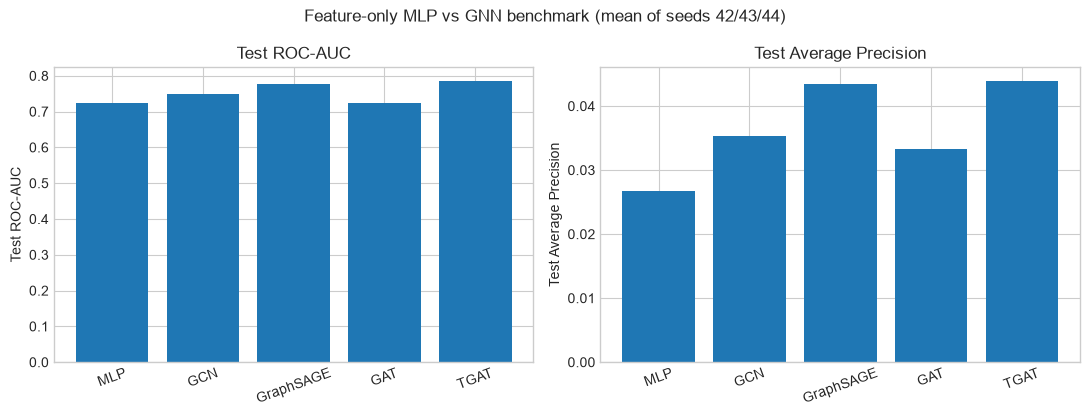

Đã lưu: artifacts\figures\sprint3\01_undirected_benchmark.png


In [14]:
SPRINT3_CATALOG_PATH = PROJECT_ROOT / "artifacts" / "metrics" / "sprint3_results.json"
SPRINT3_FIGURE_DIR = PROJECT_ROOT / "artifacts" / "figures" / "sprint3"
SPRINT3_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sprint3_catalog = load_result_catalog(SPRINT3_CATALOG_PATH)
sprint3_experiments = pd.DataFrame(sprint3_catalog["experiments"])
sprint3_runs = pd.DataFrame(sprint3_catalog["runs"])
assert set(sprint3_runs["model"]) == {"gat", "tgat"}
assert sprint3_runs.groupby("model")["seed"].nunique().eq(3).all()
assert sprint3_runs["graph_direction"].eq("undirected").all()
assert not sprint3_experiments["test_used_for_selection"].any()
assert not sprint3_experiments["is_partial_evaluation"].any()
assert sprint3_experiments["data_sha256"].nunique() == 1
assert sprint3_experiments["data_sha256"].iloc[0] == experiments_df["data_sha256"].iloc[0]

reference_runs = runs_df.loc[
    ((runs_df["experiment"] == "gcn_graphsage_ablation_undirected")
    & runs_df["model"].isin(["gcn", "graphsage"]))
    | ((runs_df["experiment"] == "mlp_zero_indicator") & (runs_df["model"] == "mlp"))
].copy()
reference_runs.loc[reference_runs["model"].isin(["gcn", "graphsage"]), "sampling_protocol"] = "static_neighbor_loader"
reference_runs.loc[reference_runs["model"].isin(["gcn", "graphsage"]), "symmetrization_policy"] = "structural_coalesced"
benchmark_runs = pd.concat([reference_runs, sprint3_runs], ignore_index=True, sort=False)

benchmark_rows = []
for model_name, group in benchmark_runs.groupby("model", sort=False):
    row = {
        "model": model_name.upper() if model_name != "graphsage" else "GraphSAGE",
        "sampling_protocol": group["sampling_protocol"].iloc[0],
        "symmetrization_policy": group["symmetrization_policy"].iloc[0],
        "seeds": group["seed"].nunique(),
        "parameters": int(group["parameter_count"].iloc[0]),
        "total_run_seconds": group["run_elapsed_seconds"].sum(),
    }
    for metric in METRICS:
        row[f"{metric}_mean"] = group[metric].mean()
        row[f"{metric}_std"] = group[metric].std(ddof=0)
    benchmark_rows.append(row)

benchmark_df = pd.DataFrame(benchmark_rows)
model_order = ["MLP", "GCN", "GraphSAGE", "GAT", "TGAT"]
benchmark_df["model"] = pd.Categorical(benchmark_df["model"], model_order, ordered=True)
benchmark_df = benchmark_df.sort_values("model").reset_index(drop=True)
display(benchmark_df.round(6))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for axis, metric, title in [
    (axes[0], "test_roc_auc_mean", "Test ROC-AUC"),
    (axes[1], "test_average_precision_mean", "Test Average Precision"),
]:
    axis.bar(benchmark_df["model"].astype(str), benchmark_df[metric])
    axis.set_title(title)
    axis.set_ylabel(title)
    axis.tick_params(axis="x", rotation=20)
fig.suptitle("Feature-only MLP vs GNN benchmark (mean of seeds 42/43/44)")
fig.tight_layout()
figure_path = SPRINT3_FIGURE_DIR / "01_undirected_benchmark.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Đã lưu:", figure_path)


## 11. Kết luận và giới hạn

- MLP feature-only thấp hơn các GNN mạnh nhất, cho thấy cấu trúc graph cung cấp tín hiệu bổ sung.
- TGAT có validation ROC-AUC/AP cao nhất trong benchmark.
- TGAT có test ROC-AUC cao nhất; test AP nhỉnh hơn GraphSAGE nhưng test không dùng để chọn model.
- GAT thấp hơn GCN trong cấu hình attention đã khóa.
- So sánh khóa direction, feature, split, seed và training budget, nhưng TGAT dùng
  event-mirror, one-hop sampler và time encoding riêng nên chỉ được diễn giải end-to-end.
- Kết quả là node-level transductive evaluation, không chứng minh dự đoán fraud tương lai
  và không tạo đầu ra nhóm gian lận.
